<a href="https://colab.research.google.com/github/Manar0887/Dustur-Multazim-Jadid/blob/main/Customer%20Segmentation%20%E2%80%93%20Retail%20E-Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [ ]:

#Importing Requierd Libraries
import pandas as pd
import numpy as np
from itertools import product
import datetime

# For interactive graphics
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns



# Sklearn
from sklearn.preprocessing import StandardScaler
import sklearn.impute
import sklearn.compose
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, AffinityPropagation, MeanShift, SpectralClustering, estimate_bandwidth
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import NearestNeighbors

# Magics Funtions
%load_ext autoreload
%autoreload 2




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Loading Datset


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/marketing_campaign.csv', sep="\t" )

In [ ]:
df.head()

\#Exploratory Data Analysis


In [ ]:
# Access the column names
df.columns


In [ ]:
# Get the dimensions of the Data
df.shape

In [ ]:
# Get a  summary of the data
df.info()

from the pervious output ,we can notic that
Dt_Customer that indicates the Date of customer's enrollment with the company
: is object not datetime
income datatype is float


there is missing value in INCOME



In [ ]:
# Generate descriptive statistics for the Data
# Calculate the descriptive statistics and round to 2 decimal places
description = df.describe().round(2)

# Apply color gradient to the descriptive statistics
colored_description = description.style.background_gradient()

# Display the colored descriptive statistics
colored_description

Note: The standard deviation for column Z_CostContact and column Z_Revenue is zero


In [ ]:
df = df.drop(['Z_Revenue', 'Z_CostContact'], axis=1)


## cheak for duplication



In [ ]:
# cheack for duplication in the data
df[df.duplicated()]

## Number of unique values present in each column



In [ ]:
#FINDING THE NUMBER OF UNIQUE VALUES PRESENT IN EACH COLUMN...
df.nunique()


#Data cleaning and manipulation


> Indented block



In [ ]:
# Checking for null value using heatmap

sns.heatmap(df.isnull())

In [ ]:
# Count the number of missing values
df.isnull().sum()

since there are some missing values in Income I will check that column and replace missing values with mean or median

In [ ]:



# Setting up colors preferences
sns.set(style="dark", palette="bright", rc={"axes.facecolor": "black", "figure.facecolor": "black"})

# Example color palette
pallet = ["#FF5733", "#C70039", "#900C3F", "#581845", "#FFC300", "#DAF7A6"]
cmap = colors.ListedColormap(pallet)
# Define the colorblind palette
#palette_color = sns.color_palette('colorblind')

# Set the plot size
plt.figure(figsize=(10, 8))

# Plot the distribution of the data
sns.histplot(df['Income'], palette=palette_color)

# Set the title color
plt.title("Income Distribution", color='white')

# Set the label color
plt.xlabel("Income")
plt.ylabel("Density")

# Display the plot
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the plot size
plt.figure(figsize=(10, 8))

# Plot the distribution of the data
sns.histplot(df['Income'], palette=palette)

# Set the title color
plt.title("Income Distribution", color='white')

# Set the label color
plt.xlabel("Income", color='white')
plt.ylabel("Density", color='white')

# Set the tick color
plt.xticks(color='white')
plt.yticks(color='white')

# Set the legend color
#plt.legend(facecolor='black', edgecolor='white')

# Set the grid color
#plt.grid(color='white')

# Display the plot
plt.show()

As we can see from the income graph, most customers have the income range of 30000–800000.



In [ ]:
# Set color-blind-friendly colors
#colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]


# Box plot
fig_box = go.Figure()
fig_box.add_trace(go.Box(x=df['Income'], marker_color="#ff7f0e"))
fig_box.update_layout(
    template="plotly_dark",  # Set the template to "plotly_dark" for a black background
    xaxis=dict(title="Income"),
)



since the data is left skewed i  will replace the missing values with median

In [ ]:
df.fillna(df.median(numeric_only=True).round(1), inplace=True)

## Outliers

In [ ]:
columns_numeric = ['Year_Birth',
               'Income', 'Recency', 'MntWines', 'MntFruits',
               'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
               'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
               'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

In [ ]:
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Set the template font
pio.templates['plotly_dark']['layout']['font'] = {'family': 'verdana', 'size': 10, 'color': 'white'}

# Set up plotly
plot_rows = 2
plot_cols = 7
fig = make_subplots(rows=plot_rows, cols=plot_cols, shared_yaxes=False)

# Add traces
x = 0
for i in range(1, plot_rows + 1):
    for j in range(1, plot_cols + 1):
        fig.add_trace(go.Box(
            y=df[columns_numeric[x]].values,
            name=df[columns_numeric].columns[x]
        ), row=i, col=j)
        x += 1

# Update layout
fig.update_layout(
    width=1500,
    height=800,
    template='plotly_dark'
)

# Show the plot
fig.show()


###Observations
In our examined graphs:


- We detect a possible outlier in the 'Income' column with a value of 666666, we will assume that it is an erroneous data or a TYPO, we will analyze how much the average of this column impacts and we will substitute the average without this value.

- We detected 3 possible outliers in the 'Year_Birth' column with values from 1900 to 1893, which, taking into account the value 1900, would have a difference of 96 years with the Year_Birth of the minor in the dataset, without adding the years until he could buy. We'll assume it's a bad data or a TYPO, analyze how much the average of this column impacts, and substitute with the average without these values.

## Transformation and preprocessing of categorical data


In [ ]:
print(df['Education'].value_counts(), '\n')
print(df['Marital_Status'].value_counts())

"Based on the  data, it seems that the majority of Customers in this dataset have completed their education up to the Graduation level, with a count of 1127. This is followed by 486 individuals who have attained a PhD, 370 individuals with a Master's degree, 203 individuals with a 2nd Cycle degree, and finally, 54 individuals with a Basic education level."

### Observations
In our examined columns:


- We don't need so many variables, with 'Under Graduate' ,graduate 'Post Graduate' they will be useful for our cases in the 'Education' column

- We don't need so many variables, with 'Relationship' and 'Single' they will be useful for our cases in the 'Marital_Status' column
In the next step, we will replace

#### Education

In [ ]:
#Segmenting education levels in three groups
df["Education"]=df["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

In [ ]:
# Set the black background style
plt.style.use('dark_background')

# Create the bar plot with the specified color palette
sns.catplot(data=df, x="Education", kind="count", palette="muted")

# Set the title and labels
plt.title('Education Distribution')
plt.xlabel('Education')
plt.ylabel('Count')

# Show the plot
plt.show()


#### Marital_Status

In [ ]:
df['Marital_Status'].value_counts()

Based on the marital status graph, most customers are already married.



In [ ]:
df["Marital_Status"]=df["Marital_Status"].replace({"Married":"Relation", "Together":"Relation", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone"})

## Convert categorical variable to datetime

In [ ]:
df['Dt_Customer'].nunique


In [ ]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
max_date = df['Dt_Customer'].max().date()

# Display the maximum date
print('max_date : ' , max_date)

max_date :  2014-12-06


<ipython-input-312-908b0dab76c2>:1: UserWarning:

Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.



# creating feature

In [ ]:
#Creating a feature ("Customer_days") of the number of days the customers started to shop in the store relative to the last recorded date
df['Day_Engaged'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

df['Day_Engaged']


0       971
1       125
2       472
3        65
4       321
       ... 
2235    541
2236     61
2237    315
2238    316
2239    782
Name: Day_Engaged, Length: 2240, dtype: int64

##AGE

In [ ]:
df['Age']= 2015 - df['Year_Birth']

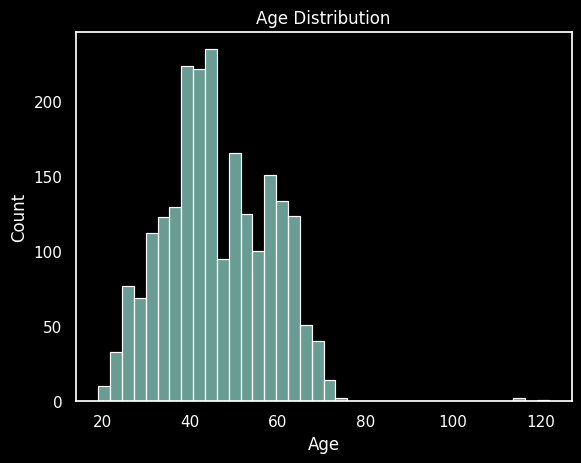

In [ ]:
ax = plt.axes()
sns.histplot(
    data=df,
    x="Age",
    fill=True,
    ax=ax,

)
ax.set_title("Age Distribution")
plt.show()

## Union of Kidhome and Teenhome variables in a single column


In [ ]:
df['Kidhome'].value_counts()


0    1293
1     899
2      48
Name: Kidhome, dtype: int64

In [ ]:
df['Teenhome'].value_counts()

0    1158
1    1030
2      52
Name: Teenhome, dtype: int64

### Observations
In our examined columns:


- We don't need two columns to represent the presence of children in the household, so we'll merge them into a single variable called 'children'.

##  Combining different dataframe into a single column to reduce the number of dimension


## Children

In [ ]:
df['Children'] = df['Kidhome'] + df['Teenhome']


In [ ]:
df['Has_Children']  = np.where(df.Children> 0, 1, 0)

##Total_Expenses

In [ ]:
#Create another feature "Money_Spent" indicating the total amount spent by the customer in various categories
mnt_cols = [col for col in df.columns if 'Mnt' in col]
df['Total_Expenses'] = df[mnt_cols].sum(axis=1)

##Total_purchase

In [ ]:
# Total Purchases
purchases_cols = [col for col in df.columns if 'Purchases' in col]
df['TotalPurchases'] = df[purchases_cols].sum(axis=1)

##Total camp

In [ ]:
# Total Campaigns Accepted
campaigns_cols = [col for col in df.columns if 'Cmp' in col] + ['Response'] # 'Response' is for the latest campaign
df['Accepted_Campaign'] = df[campaigns_cols].sum(axis=1)

In [ ]:
# Changing some feature name for clarity
df=df.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

## Elimination of redundant features


---


Observations

- Next, we will eliminate some of the columns of variables that are contained in other variables or that do not contribute information. These columns include the  Teenhome, and Kidhome.

In [ ]:
to_drop = [ "Dt_Customer", "Year_Birth", "ID"]
df = df.drop(to_drop, axis=1)

##Dropping outliers

In [ ]:
df = df[(df["Age"]<90)]
df = df[(df["Income"]<300000 )]
print("The size of data after removing the outliers:", df.shape)


The size of data after removing the outliers: (2236, 31)


Note:-In above cell "Z_CostContact" and "Z_Revenue" have same value in all the rows that's why , they are not going to contribute anything in the model building. So i will drop them.

#Distribuation analysis

## Analysis by Income


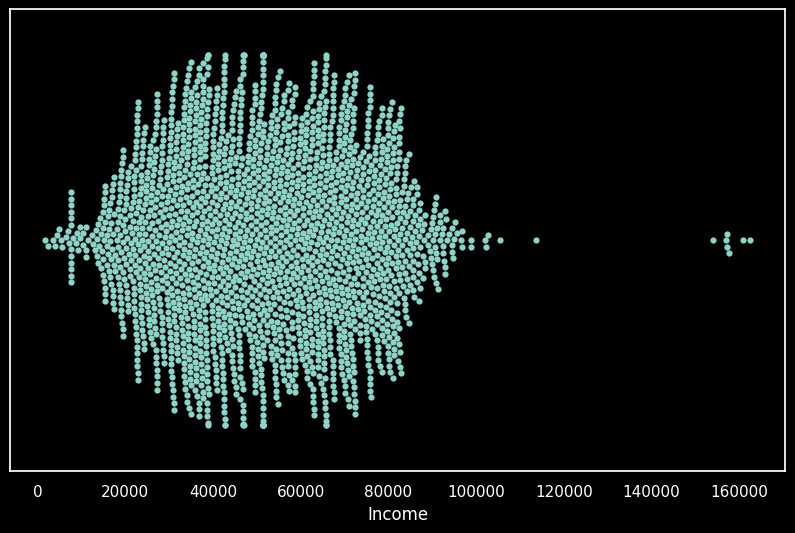

In [ ]:
# Set the black background style
plt.style.use('dark_background')

# Set the figure size
plt.figure(figsize=(10, 6))

# Create the swarm plot with the specified size
g = sns.swarmplot(data=df, x='Income', s=4.5, orient="h")

# Show the plot
plt.show(g)

## Analysis by Age


In [ ]:
# Set the figure size
plt.figure(figsize=(10, 6))
g = sns.swarmplot(data=df, x='Age', s=4.5, orient="h")

plt.show(g)

In [ ]:
subplots_edad = df.groupby(['Age']).sum()

In [ ]:
fig = make_subplots(
    rows=4,
    cols=1,
    subplot_titles=(
        "NumStorePurchases for age",
        "NumWebPurchases for ",
        "NumWebVisitsMonth for Year_Birth",
        "NumCatalogPurchases for Year_Birth"
    ),
    shared_xaxes=True,
    vertical_spacing=0.1
)

fig.add_trace(go.Scatter(x=subplots_edad.index, y=subplots_edad.NumStorePurchases, mode="lines", name="NumStorePurchases", opacity=0.8),
    row=1,
    col=1,
)

fig.add_trace(go.Scatter(x=subplots_edad.index, y=subplots_edad.NumWebPurchases, mode="lines", name="NumWebPurchases", opacity=0.8),
    row=2,
    col=1,
)

fig.add_trace(go.Scatter(x=subplots_edad.index, y=subplots_edad.NumWebVisitsMonth, mode="lines", name="NumWebVisitsMonth", opacity=0.8),
    row=3,
    col=1,
)

fig.add_trace(go.Scatter(x=subplots_edad.index, y=subplots_edad.NumCatalogPurchases, mode="lines", name="NumCatalogPurchases", opacity=0.8),
    row=4,
    col=1,
)

fig.update_layout(title_text="Subplots variables Place of Dataset")

fig.show()

In [ ]:
df[['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']].sum().sort_values().plot(kind='barh', figsize=(12, 7))
plt.title('Expenses', pad=15, fontsize=18, fontweight='semibold')

plt.show()

Based on the total expenses graph, wine has the highest sell amount.

In [ ]:
ax = df[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum().sort_values(ascending=True).plot(kind='barh')
plt.title('Purchases', pad=15, fontsize=18, fontweight='semibold')

Based on the number purchases category graph, number of purchases made directly in stores is the highest.

In [ ]:
df['Accepted_Campaign'].value_counts()

In [ ]:
ax = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4','AcceptedCmp5', 'Response']].sum().sort_values(ascending=True).plot(kind='barh')
plt.title('Accepted Campaign', pad=15, fontsize=18, fontweight='semibold')

Based on the accepted campaign graph, we can know that the more campaign done by the company, the more people accepted the campaign. The highest value is on response, which who accepted the last campaign.

<Figure size 640x480 with 0 Axes>

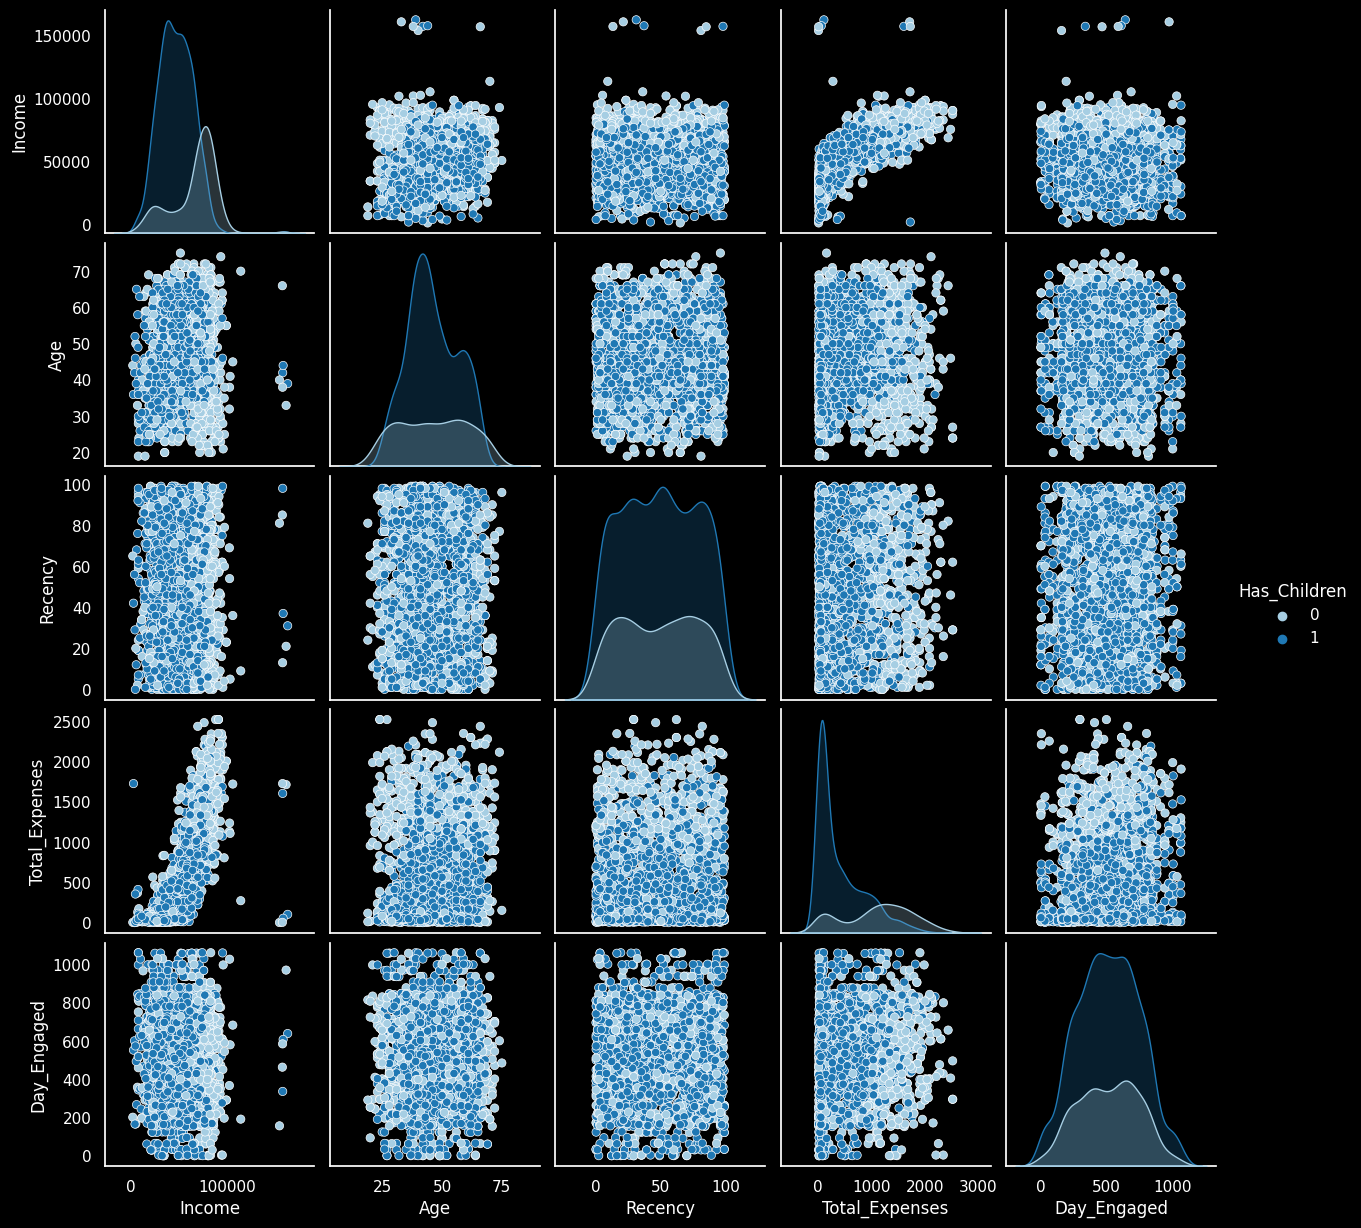

In [ ]:
To_Plot = ["Income", "Age", "Recency", "Total_Expenses", "Has_Children", "Day_Engaged"]
plt.figure()
sns.pairplot(df[To_Plot], hue= "Has_Children" , palette="Paired")
#Taking hue
plt.show()


In [ ]:
sns.set_theme(style="black")
plt.figure(figsize=(8,8))
plt.title("How TotalPurchases Impacts on Total_Expenses ?",fontsize=15)
plt.xticks(rotation=90)
ax = sns.barplot(x="TotalPurchases", y="Total_Expenses", data=df,palette="Paired")


ValueError: ignored

In [ ]:
sns.set_theme(style="white")
plt.figure(figsize=(20,8))
plt.title("How Days Engaged impacts on Expenses?",fontsize=24)
plt.xticks(rotation=90)
ax = sns.lineplot(x="Customer_Days", y="Total_Expenses", data=df,palette="gist_earth")

In [ ]:
# Calculate correlation matrix
corrs = df.select_dtypes(include=np.number).corr(method='kendall')

# Plot clustered heatmap of correlations
sns.clustermap(corrs, cbar_pos=(-0.05, 0.8, 0.05, 0.18), cmap='coolwarm', center=0)

In [ ]:
products = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntGoldProds']

for _ in products:
    fig = px.histogram(df, x='Year_Customer', y=_, color="Month_Customer", barmode='relative', title="Mnts for Year_Customer")
    fig.update_layout(width=800, height=600, bargap=0.2)
    fig.update_xaxes(tickvals=[2012, 2013, 2014])
    fig.show()

#DATA PREPROCESSING

##Copy the data


Sometimes I like to copy my data so I’ll still able to look through the original data

## Droping redunant columns

Next, I’m dropping features that I think I’m no longer going to need anymore



In [ ]:
#df = df.drop(['ID', 'Year_Birth', 'Marital_Status','Dt_Customer',  'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5','Response', 'Complain'], axis=1)



The following steps are applied to preprocess the data:

Label encoding the categorical features
Scaling the features using the standard scaler
Creating a subset dataframe for dimensionality reduction





In [ ]:
df

In [ ]:
# Getting list of categorical variables
## variable category contains the names of coulmns whose data type is object
category = (df.dtypes == 'object')
object_cols = list(category[category].index)

print("Categorical variables in the dataset:", object_cols)

## Label encoding

Now, time for encoding. There are 2 features that needs to be encoded. Education and Relation .

In [ ]:
"""
print('Before label encoding')
print(df[['Education', 'Relation']])

# Label Encoding the object dtypes.
LE=LabelEncoder()
for i in  object_cols:
    df[i]=df[[i]].apply(LE.fit_transform)
print('**********************************')
print('After label encoding')
print(df[['Education', 'Relation']])
"""

In [ ]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
LE.fit(df['Marital_Status'])
df['Relation'] = LE.transform(df['Marital_Status'])


In [ ]:
# Getting list of categorical variables
## variable cv contains the names of coulmns whose data type is object
cv = (df.dtypes == 'object')
cat_var = list(cv[cv].index)

print("Categorical variables in the dataset:", cat_var)

In [ ]:
df.info()

In [ ]:
#Creating a copy of data
data = df.copy()

In [ ]:
data


##Scaling

In [ ]:
#Scaling
scaler = StandardScaler()
scaler.fit(data)
scaled_ds = pd.DataFrame(scaler.transform(data),columns= data.columns )

In [ ]:
#Scaled data to be used for reducing the dimensionality
print("Dataframe to be used for further modelling:")
scaled_ds.head()

#Dimensionality Reduction:

In [ ]:
#Initiating PCA to reduce dimentions aka features to 3
pca = PCA(n_components=3)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=(["col1","col2", "col3"]))
PCA_ds.describe().T

In [ ]:
#A 3D Projection Of Data In The Reduced Dimension
x =PCA_ds["col1"]
y =PCA_ds["col2"]
z =PCA_ds["col3"]
#To plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x,y,z)
ax.set_title("A 3D Projection Of Data In The Reduced Dimension")
plt.show()

#Clustering:
Now that I have reduced the attributes to three dimensions, I will be performing clustering via Agglomerative clustering. Agglomerative clustering is a hierarchical clustering method. It involves merging examples until the desired number of clusters is achieved.

Steps involved in the Clustering:

Elbow Method to determine the number of clusters to be formed
Clustering via Agglomerative Clustering
Examining the clusters formed via scatter plot

In [ ]:
# Quick examination of elbow method to find numbers of clusters to make.
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(PCA_ds)
Elbow_M.show()

In [ ]:
#Initiating the Agglomerative Clustering model
AC = AgglomerativeClustering(n_clusters=4)
# fit model and predict clusters
yhat_AC = AC.fit_predict(PCA_ds)
PCA_ds["Clusters"] = yhat_AC
#Adding the Clusters feature to the orignal dataframe.
data["Clusters"]= yhat_AC

In [ ]:
# Import KMeans
from sklearn.cluster import KMeans

# Create a KMeans instance with 3 clusters: model
model = KMeans(n_clusters=3)

# Fit model to points
model.fit(PCA_ds)

# Determine the cluster labels of new_points: labels
labels = model.predict(PCA_ds) +1

# Print cluster labels of new_points
PCA_ds["Clusters"] = labels
#Adding the Clusters feature to the orignal dataframe.
data["Clusters"]= labels



In [ ]:
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection='3d')
ax.scatter(x, y, z, s=40, c=PCA_ds["Clusters"])
ax.set_title("The Plot Of The Clusters")
plt.show()

In [ ]:
data


In [ ]:
import plotly.express as px

fig = px.scatter_3d(data, x=x, y=y, z=z, color=data['Clusters'], size_max=6,
    opacity=0.8,
    title="The Plot Of The Clusters" ,

                    labels={'x': 'Feature 1', 'y': 'Feature 2', 'z': 'Feature 3'})

fig.show()

In [ ]:

# Assign the cluster centers: centroids
centroids = model.cluster_centers_

# Assign the columns of centroids: centroids_x, centroids_y
centroids_x = centroids[:,0]
centroids_y = centroids[:,1]

# Make a scatter plot of centroids_x and centroids_y
plt.scatter(centroids_x ,centroids_y , marker='D' ,s=50 )
plt.show()


#EVALUATING MODELS

In [ ]:
#Plotting countplot of clusters
# pal = ["#682F2F","#B9C0C9", "#9F8A78","#F3AB60"]
pl = sns.countplot(x=data[""])
pl.set_title("Distribution Of The Clusters")
plt.show()

In [ ]:
sns.scatterplot(x='Total_Expenses', y='Income', hue='cluster_Kmeans', data=data_prep)

Income vs spending plot shows the clusters pattern

group 0: high spending & average income
group 1: high spending & high income
group 2: low spending & low income
group 3: high spending & low income

In this problem, there are many factors on the basis of which the final classification will be done. These factors are basically attributes or features. The higher the number of features, the harder it is to work with it. Many of these features are correlated, and hence redundant. This is why I will be performing dimensionality reduction on the selected features before putting them through a classifier.
Dimensionality reduction is the process of reducing the number of random variables under consideration, by obtaining a set of principal variables.

Principal component analysis (PCA) is a technique for reducing the dimensionality of such datasets, increasing interpretability but at the same time minimizing information loss.

Steps in this section:

Dimensionality reduction with PCA
Plotting the reduced dataframe
Dimensionality reduction with PCA

For this project, I will be reducing the dimensions to 4.